In [1]:
import torch
import numpy as np
import pandas as pd

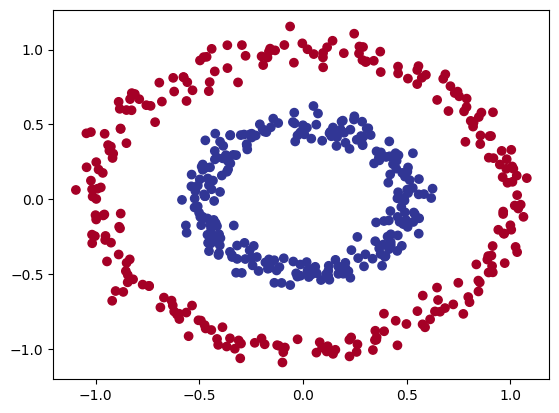

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

x,y = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)

plt.scatter(x[:,0], x[:,1], c=y, cmap=plt.cm.RdYlBu)
plt.show()

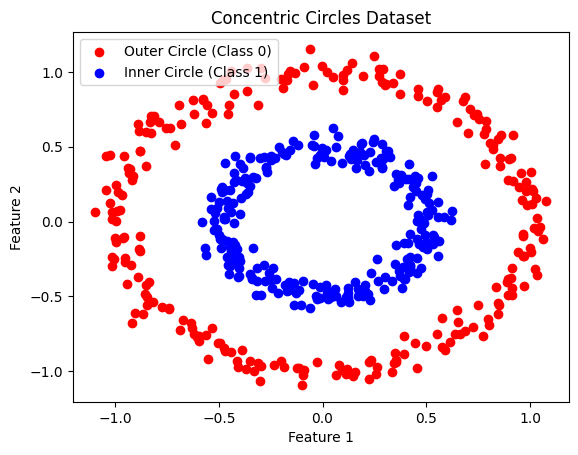

In [4]:
# X contains coordinates (x, y); y contains labels (0 for outer circle, 1 for inner circle)
plt.scatter(x[y == 0, 0], x[y == 0, 1], color='red', label='Outer Circle (Class 0)')
plt.scatter(x[y == 1, 0], x[y == 1, 1], color='blue', label='Inner Circle (Class 1)')

plt.title("Concentric Circles Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [5]:
import torch.nn as nn
import torch.optim as optim

In [10]:
class CircleModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self,x):
    x = self.layer_1(x)
    x = torch.relu(x)
    x = self.layer_2(x)
    return x

In [11]:
model = CircleModel()

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:

X_train_tensor = torch.from_numpy(x_train).float()
y_train_tensor = torch.from_numpy(y_train).float().unsqueeze(1)
X_test_tensor = torch.from_numpy(x_test).float()
y_test_tensor = torch.from_numpy(y_test).float().unsqueeze(1)

with torch.inference_mode():
  logits = model(X_train_tensor)
  loss_fn = nn.BCEWithLogitsLoss()
  loss = loss_fn(logits, y_train_tensor)
  print(loss)

tensor(0.6950)


In [20]:
optimizer = optim.Adam(params=model.parameters(), lr=0.1)

In [21]:
epochs = 100

for e in range(epochs):
  # train
  model.train()

  logits = model(X_train_tensor)
  loss_fn = nn.BCEWithLogitsLoss()
  loss = loss_fn(logits, y_train_tensor)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if e % 10 == 0:
    print(f"Epoch: {e} | Train Loss: {loss:.4f}")

  #test
  model.eval()
  with torch.inference_mode():
    logits = model(X_test_tensor)
    loss_fn = nn.BCEWithLogitsLoss()
    loss = loss_fn(logits, y_test_tensor)
  if e % 10 == 0:
    print(f"Epoch: {e} | Test Loss: {loss:.4f}")

Epoch: 0 | Train Loss: 0.6813
Epoch: 0 | Test Loss: 0.6995
Epoch: 10 | Train Loss: 0.5387
Epoch: 10 | Test Loss: 0.5133
Epoch: 20 | Train Loss: 0.3052
Epoch: 20 | Test Loss: 0.2635
Epoch: 30 | Train Loss: 0.1373
Epoch: 30 | Test Loss: 0.1137
Epoch: 40 | Train Loss: 0.0696
Epoch: 40 | Test Loss: 0.0533
Epoch: 50 | Train Loss: 0.0429
Epoch: 50 | Test Loss: 0.0286
Epoch: 60 | Train Loss: 0.0313
Epoch: 60 | Test Loss: 0.0198
Epoch: 70 | Train Loss: 0.0251
Epoch: 70 | Test Loss: 0.0152
Epoch: 80 | Train Loss: 0.0212
Epoch: 80 | Test Loss: 0.0120
Epoch: 90 | Train Loss: 0.0185
Epoch: 90 | Test Loss: 0.0102


In [24]:
def accuracy(y_preds,y_true):
  count =0
  for y,y_hat in zip(y_preds,y_true):
    if y == y_hat:
      count += 1
  return count/len(y_preds)


In [25]:
model.eval()
with torch.inference_mode():
  logits = model(X_test_tensor)
y_preds = torch.round(torch.sigmoid(logits))
print(f"Accuracy: {accuracy(y_preds,y_test_tensor)}")

Accuracy: 1.0


In [26]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

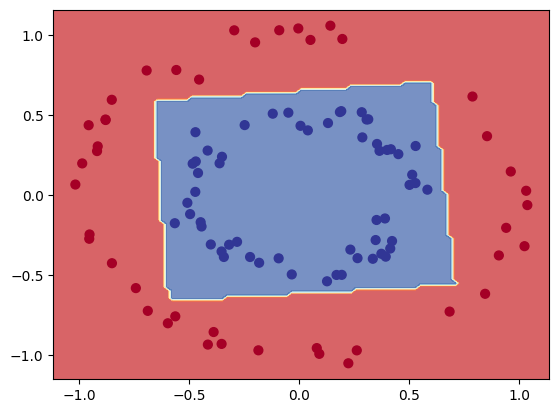

In [27]:
plot_decision_boundary(model,X_test_tensor,y_test_tensor)
